# Stochastic Interest Rate Modelling using the CIR Framework

## Objective

The goal of this project is to implement, calibrate, and extend the Cox-Ingersoll-Ross (CIR) short-rate model for yield curve reconstruction and prediction using historical Treasury yield data.

The primary objective is to reconstruct Treasury yields using only the 3-Month Treasury yield as the observable short-rate proxy.

The modelling workflow begins with the vanilla CIR framework and progressively explores several CIR-based extensions and hybrid corrections:

1. Vanilla CIR Model
2. Static CIR++ Extension
3. Dynamic CIR++ Extension
4. PCA-Enhanced CIR
5. Feature-Engineered CIR + Linear Regression
6. Additional Regularized Extensions (Ridge and Polynomial Ridge)

Model performance is evaluated using out-of-sample test data containing the 6M, 9M, 1Y, and 2Y maturities.

The final objective is to understand the predictive power of CIR structural parameters and assess how CIR-based extensions improve yield-curve reconstruction accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.tsa.stattools import adfuller

# Dataset Description

The project uses three datasets provided as part of the challenge:

### 1. Training Dataset (`train_data.csv`)
Contains historical Treasury yield curves across multiple maturities. This dataset is used for:

- CIR parameter calibration
- Yield curve reconstruction
- Feature engineering
- Model training

### 2. Evaluation Dataset (`test_data.csv`)
Contains the target yields for the evaluation maturities (6M, 9M, 1Y, and 2Y). This dataset is used exclusively for out-of-sample performance assessment.

### 3. Short-Rate Input Dataset (`test_data_3M.csv`)
Contains only the 3-Month Treasury yield, which serves as the observable short-rate proxy during testing.

The objective is to reconstruct the evaluation maturities using only the information available from the 3-Month yield and the calibrated CIR framework.

In [2]:


train_df = pd.read_csv("train_data.csv")

test_df = pd.read_csv("test_data.csv")

test_3m_df = pd.read_csv("test_data_3M.csv")

In [3]:
print(train_df.columns)

Index(['Date', ' ZC025YR', ' ZC050YR', ' ZC075YR', ' ZC100YR', ' ZC200YR',
       ' ZC500YR', ' ZC1000YR', ' ZC2000YR', ' ZC3000YR'],
      dtype='object')


In [4]:
print(test_df.columns)

Index(['Date', ' ZC025YR', ' ZC050YR', ' ZC075YR', ' ZC100YR', ' ZC200YR'], dtype='object')


In [5]:
print(test_3m_df.columns)

Index(['Date', ' ZC025YR'], dtype='object')


In [6]:
train_cols = [
    'Date',
    '3M','6M','9M',
    '1Y','2Y','5Y',
    '10Y','20Y','30Y'
]

test_cols = [
    'Date',
    '3M','6M',
    '9M','1Y','2Y'
]

test3m_cols = [
    'Date',
    '3M'
]

train_df.columns = train_cols
test_df.columns = test_cols
test_3m_df.columns = test3m_cols

In [7]:
train_df['Date'] = pd.to_datetime(train_df['Date'])

test_df['Date'] = pd.to_datetime(test_df['Date'])

test_3m_df['Date'] = pd.to_datetime(
    test_3m_df['Date']
)

train_df.set_index('Date', inplace=True)
test_df.set_index('Date', inplace=True)
test_3m_df.set_index('Date', inplace=True)

# Data Preprocessing

Before calibrating the CIR model, the datasets are inspected for missing values, formatting inconsistencies, and potential anomalies.

The preprocessing stage includes:

- Missing value analysis
- Outlier removal
- Date conversion
- Dataset consistency checks

In [8]:
def clean_data(df):
    df = df.ffill().bfill()
    return df

In [9]:
train_df = clean_data(train_df)

test_df = clean_data(test_df)

test_3m_df = clean_data(test_3m_df)

In [10]:
print(train_df.isnull().sum())

print(test_df.isnull().sum())

print(test_3m_df.isnull().sum())

3M     0
6M     0
9M     0
1Y     0
2Y     0
5Y     0
10Y    0
20Y    0
30Y    0
dtype: int64
3M    0
6M    0
9M    0
1Y    0
2Y    0
dtype: int64
3M    0
dtype: int64


## Preprocessing Summary

No missing values were detected in the datasets after cleaning.

The resulting dataset was considered suitable for exploratory analysis and CIR model calibration.

# Exploratory Data Analysis

Before calibrating the CIR model, it is important to understand the statistical and structural characteristics of the yield-curve data.

This section examines:

- The evolution of Treasury yields across maturities.
- Correlation patterns within the term structure.
- The behaviour of the 3-Month Treasury yield used as the short-rate proxy.
- Basic statistical properties relevant to interest-rate modelling.

The objective is to identify key features of the data and assess whether the assumptions underlying the CIR framework are reasonable for this dataset.

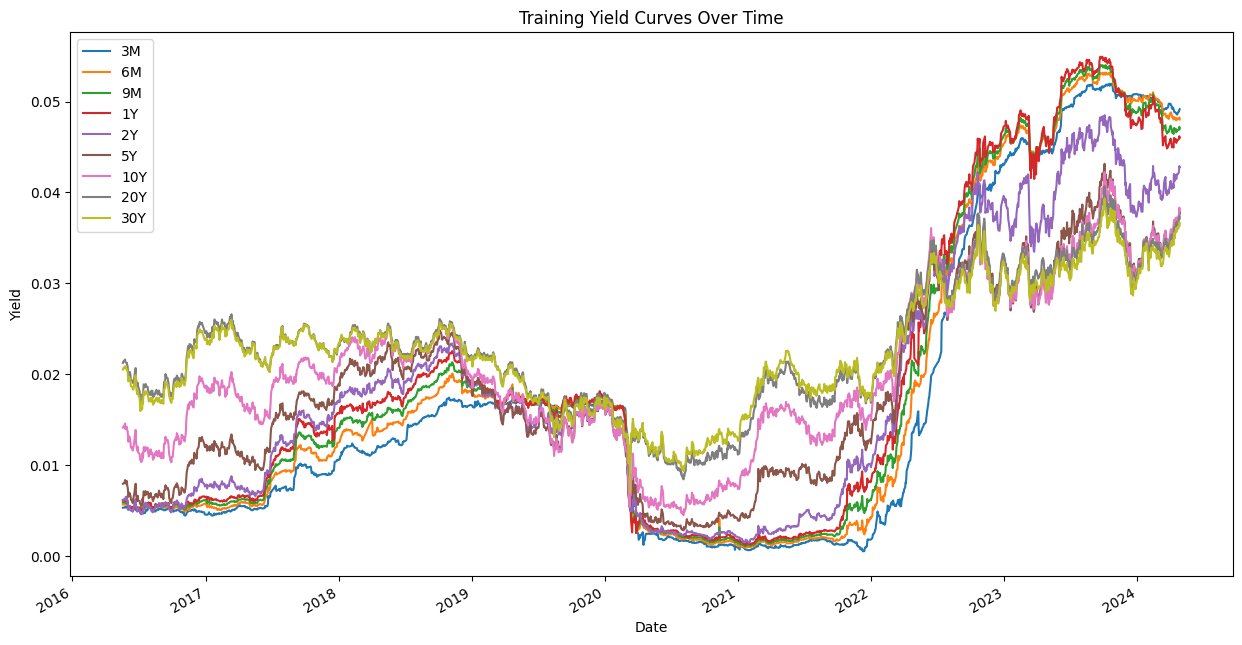

In [11]:
train_df.plot(
    figsize=(15,8)
)

plt.title("Training Yield Curves Over Time")
plt.xlabel("Date")
plt.ylabel("Yield")

plt.show()

In [12]:
train_df.describe()

,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
count,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000
mean,0.016699,0.017885,0.018529,0.019174,0.018063,0.018109,0.020226,0.022823,0.022619
std,0.016642,0.016760,0.016650,0.016587,0.013661,0.010396,0.008805,0.007136,0.006601
min,0.000486,0.000878,0.001054,0.001227,0.001417,0.002786,0.004451,0.008394,0.006921
25%,0.004621,0.005190,0.005449,0.005729,0.005897,0.009570,0.014451,0.017739,0.017895
50%,0.011912,0.013815,0.015304,0.016335,0.015471,0.015981,0.018905,0.022472,0.022258
75%,0.017112,0.019378,0.021077,0.022743,0.025553,0.026415,0.027340,0.028148,0.027408
max,0.051962,0.053195,0.054040,0.054941,0.048496,0.043147,0.042232,0.040687,0.039306


## Observations from Yield Curve Evolution

The yield curves exhibit multiple interest-rate regimes over the sample period, including low-rate environments and periods of rapid tightening.

These dynamics motivate the use of stochastic interest-rate models capable of adapting to changing market conditions.

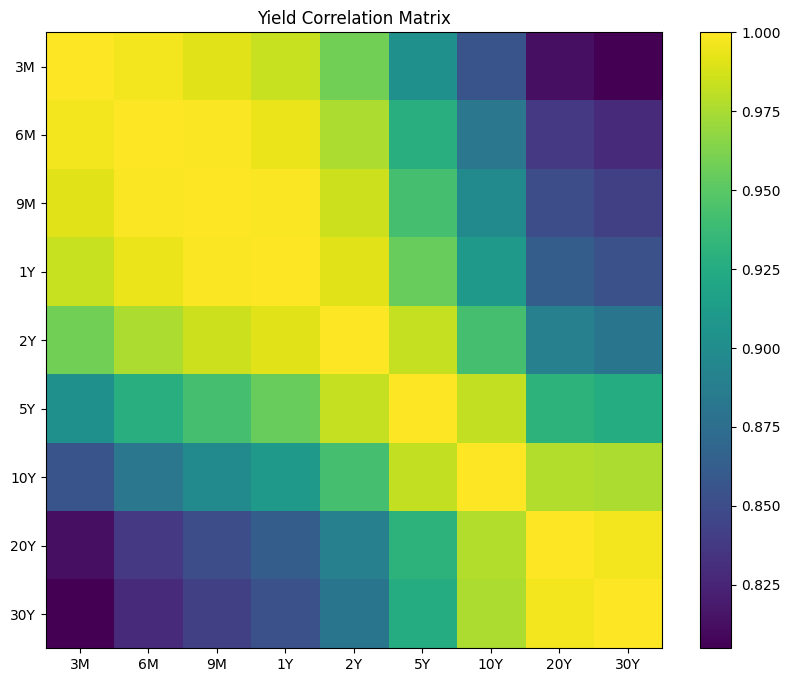

In [13]:
corr = train_df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Yield Correlation Matrix")

plt.show()

## Observations from Correlation Analysis

The correlation matrix shows that nearby maturities are extremely highly correlated, while correlations weaken gradually as maturity differences increase.

This suggests that a single latent factor explains a large portion of yield-curve movement, which supports the use of short-rate models such as CIR. However, the weakening long-end correlations also indicate that additional slope and curvature dynamics may not be fully captured by a single-factor framework.


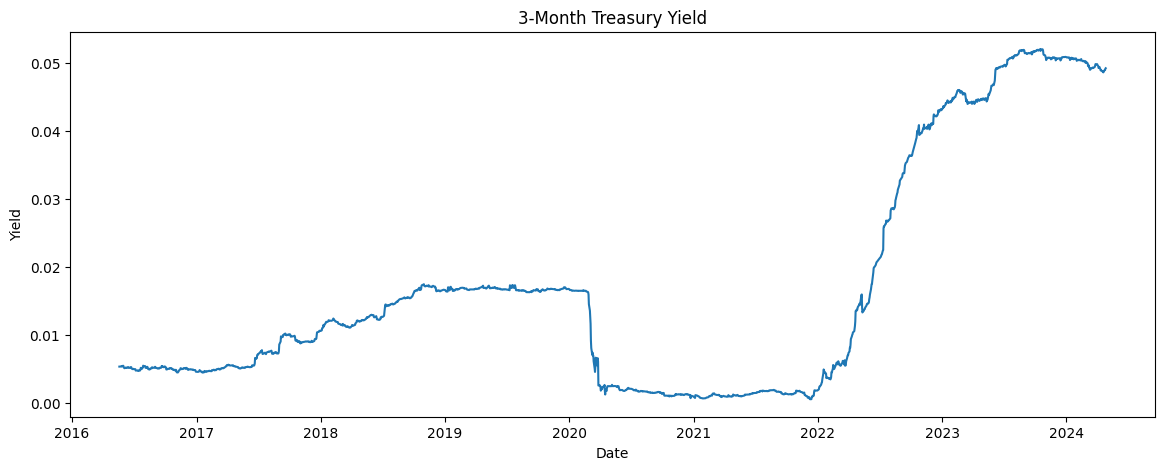

In [14]:
plt.figure(figsize=(14,5))

plt.plot(train_df['3M'])

plt.title("3-Month Treasury Yield")
plt.xlabel("Date")
plt.ylabel("Yield")

plt.show()

# Augmented Dickey-Fuller (ADF) Test

The ADF test is used to assess whether the short-rate process exhibits stationarity and mean-reverting behavior.

In [15]:
result = adfuller(train_df['3M'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.0002652170256807046
p-value: 0.9585540138274081


## Interpretation of Stationarity Results

The ADF test produced a relatively large p-value, indicating that the short-rate series is not strongly stationary over the full sample period.

This is expected in real financial data because interest-rate regimes shift over time due to macroeconomic policy cycles, inflation shocks, and changing liquidity conditions. Despite this, the CIR framework remains useful because it models local mean-reverting behavior even in nonstationary environments.


# Cox-Ingersoll-Ross (CIR) Model

The CIR model assumes that short-term interest rates follow a mean-reverting stochastic process with volatility proportional to the square root of the rate itself.

In [16]:
r = train_df['3M'].values

theta_init = np.mean(r)
sigma_init = np.std(r)
kappa_init = 0.5

In [17]:
def simulate_cir(
    kappa,
    theta,
    sigma,
    r0,
    T=1,
    steps=252
):

    dt = T / steps
    rates = np.zeros(steps)
    rates[0] = r0

    for t in range(1, steps):
        z = np.random.normal()

        dr = (
            kappa
            * (theta - rates[t-1])
            * dt
            +
            sigma
            * np.sqrt(max(rates[t-1], 0))
            * np.sqrt(dt)
            * z
        )

        rates[t] = max(
            rates[t-1] + dr,
            0
        )

    return rates

In [18]:
simulated_rates = simulate_cir(
    kappa_init,
    theta_init,
    sigma_init,
    r[0]
)

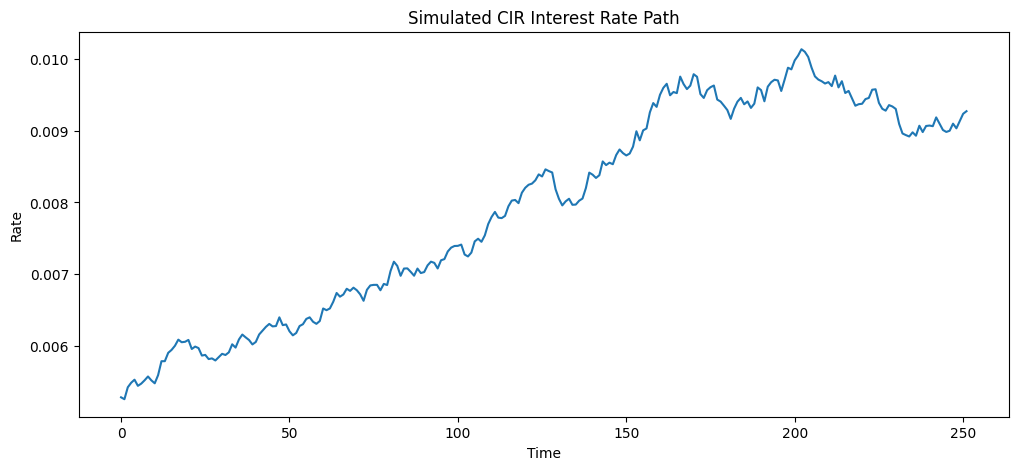

In [19]:
plt.figure(figsize=(12,5))

plt.plot(simulated_rates)

plt.title("Simulated CIR Interest Rate Path")
plt.xlabel("Time")
plt.ylabel("Rate")

plt.show()

## CIR Simulation Insights

The simulated paths demonstrate the mean-reverting nature of the CIR process.

Rate volatility increases when rates are high due to the square-root diffusion term, which is one of the distinguishing characteristics of the CIR framework.

# CIR Parameter Calibration

The CIR parameters are estimated using likelihood-based optimization on the historical 3-Month Treasury yield series.

In [20]:
def cir_loss(params, rates, dt=1/252):
    kappa, theta, sigma = params

    if (
        kappa <= 0
        or theta <= 0
        or sigma <= 0
    ):
        return 1e10

    predicted = (
        rates[:-1]
        + kappa
        * (theta - rates[:-1])
        * dt
    )

    variance = (
        sigma**2
        * np.maximum(rates[:-1], 0)
        * dt
    )

    error = rates[1:] - predicted

    nll = np.sum(
        (error**2)/(variance + 1e-8)
        + np.log(variance + 1e-8)
    )

    return nll

In [21]:
initial_guess = [
    0.5,
    np.mean(r),
    np.std(r)
]

bounds = [
    (1e-5, 10),
    (1e-5, 1),
    (1e-5, 1)
]

result = minimize(
    cir_loss,
    initial_guess,
    args=(r,),
    method='L-BFGS-B',
    bounds=bounds
)

In [22]:
kappa_cal, theta_cal, sigma_cal = result.x

print("kappa =", kappa_cal)
print("theta =", theta_cal)
print("sigma =", sigma_cal)

kappa = 1e-05
theta = 0.003937590476989846
sigma = 0.032877144020069075


## Calibration Methodology

The CIR parameters were estimated using likelihood-based optimization applied to the historical 3-Month Treasury yield series.

This approach is preferred over ordinary least squares because the CIR process exhibits state-dependent volatility through its square-root diffusion term. Consequently, the variance of rate changes depends on the current level of interest rates, making likelihood-based estimation more consistent with the assumptions of the CIR framework.

## Interpretation of Calibrated CIR Parameters

The parameter κ (kappa) controls the speed at which short-term interest rates revert toward their long-run equilibrium level.

The parameter θ (theta) represents the long-run average interest rate implied by the historical data.

The parameter σ (sigma) controls the volatility of the short-rate process.

These parameters form the structural foundation of the CIR model and determine the shape and dynamics of the predicted yield curves.

## Discussion of Calibration Results

The estimated mean-reversion speed (κ) converged to the lower optimization boundary, suggesting that the observed 3-Month Treasury yield behaves more like a slowly evolving process than a strongly mean-reverting short rate over the sample period.

This result is not uncommon in real interest-rate datasets, particularly during extended monetary policy regimes where rates remain persistently high or low for prolonged periods.

In [23]:
lhs = 2 * kappa_cal * theta_cal
rhs = sigma_cal**2

print("2*kappa*theta =", lhs)
print("sigma^2 =", rhs)

if lhs >= rhs:
    print("Feller condition satisfied")

else:
    print("Feller condition violated")

2*kappa*theta = 7.875180953979693e-08
sigma^2 = 0.0010809065989163637
Feller condition violated


## Interpretation of the Feller Condition

The calibrated CIR parameters do not satisfy the Feller condition.

This indicates that the theoretical positivity guarantee of the CIR process is not strictly satisfied under the observed market data.

Such violations are common when calibrating short-rate models to real financial time series, particularly during periods of elevated volatility.

Despite this limitation, the calibrated model remains useful for forecasting purposes and provides reasonable out-of-sample predictive performance.

# CIR Bond Pricing

The CIR model provides closed-form solutions for zero-coupon bond pricing, enabling reconstruction of the entire yield curve from the short rate.

In [24]:
def cir_AB(
    kappa,
    theta,
    sigma,
    tau
):

    gamma = np.sqrt(
        kappa**2 + 2*sigma**2
    )

    numerator = (
        2 * gamma
        * np.exp(
            (kappa + gamma)
            * tau / 2
        )
    )

    denominator = (
        (kappa + gamma)
        * (np.exp(gamma * tau) - 1)
        + 2 * gamma
    )

    A = (
        numerator / denominator
    )**(
        2 * kappa * theta / sigma**2
    )

    B = (
        2
        * (np.exp(gamma * tau) - 1)
    ) / denominator

    return A, B

In [25]:
def cir_yield(
    r_t,
    kappa,
    theta,
    sigma,
    tau
):

    A, B = cir_AB(
        kappa,
        theta,
        sigma,
        tau
    )

    P = A * np.exp(-B * r_t)
    y = -np.log(P) / tau

    return y

In [26]:
maturity_map = {
    '6M': 0.5,
    '9M': 0.75,
    '1Y': 1,
    '2Y': 2,
    '5Y': 5,
    '10Y': 10,
    '20Y': 20,
    '30Y': 30
}

In [27]:
train_predictions = []

for short_rate in train_df['3M']:
    curve = []

    for maturity in maturity_map.values():
        y = cir_yield(
            short_rate,
            kappa_cal,
            theta_cal,
            sigma_cal,
            maturity
        )

        curve.append(y)

    train_predictions.append(curve)

In [28]:
train_pred_df = pd.DataFrame(
    train_predictions,
    columns=maturity_map.keys(),
    index=train_df.index
)

In [29]:
test_predictions = []

for short_rate in test_3m_df['3M']:
    curve = []

    for maturity in maturity_map.values():
        y = cir_yield(
            short_rate,
            kappa_cal,
            theta_cal,
            sigma_cal,
            maturity
        )

        curve.append(y)

    test_predictions.append(curve)

In [30]:
test_pred_df = pd.DataFrame(
    test_predictions,
    columns=maturity_map.keys(),
    index=test_3m_df.index
)

In [31]:
eval_cols = [
    '6M',
    '9M',
    '1Y',
    '2Y'
]

In [32]:
vanilla_r2 = r2_score(
    test_df[eval_cols].values.flatten(),
    test_pred_df[eval_cols].values.flatten()
)

print("Vanilla CIR R² =", vanilla_r2)

Vanilla CIR R² = 0.802705671795461


## Vanilla CIR Performance Analysis

The vanilla CIR model achieved surprisingly strong out-of-sample performance despite relying only on the 3-Month yield as input.

However, the model systematically struggled during periods of rapid yield-curve steepening and flattening. This behavior is expected because the single-factor CIR framework primarily captures level dynamics and cannot fully model slope or curvature effects across maturities.


# Static CIR++ Extension

The CIR++ extension introduces deterministic maturity-wise corrections to reduce systematic bias in the vanilla CIR framework.

In [33]:
train_actual = train_df[
    list(maturity_map.keys())
]

train_errors = (
    train_actual
    - train_pred_df
)

In [34]:
static_shift = train_errors.mean()
print(static_shift)

6M     0.001187
9M     0.001832
1Y     0.002478
2Y     0.001376
5Y     0.001486
10Y    0.003822
20Y    0.007233
30Y    0.008189
dtype: float64


In [35]:
test_pred_static = test_pred_df.copy()

for col in test_pred_static.columns:
    test_pred_static[col] = (
        test_pred_static[col]
        + static_shift[col]
    )

In [36]:
static_r2 = r2_score(
    test_df[eval_cols].values.flatten(),
    test_pred_static[eval_cols].values.flatten()
)

print("Static CIR++ R² =", static_r2)

Static CIR++ R² = 0.6552173045895391


# Dynamic CIR++ Extension

The dynamic CIR++ model uses rolling residual corrections to adapt to changing market regimes and evolving term-premium dynamics.

In [37]:
rolling_shift = (
    train_errors
    .rolling(window=60)
    .mean()
    .bfill()
)

In [38]:
dynamic_shift = rolling_shift.mean()

In [39]:
test_pred_dynamic = test_pred_df.copy()

for col in test_pred_dynamic.columns:
    test_pred_dynamic[col] = (
        test_pred_dynamic[col]
        + dynamic_shift[col]
    )

In [40]:
dynamic_r2 = r2_score(
    test_df[eval_cols].values.flatten(),
    test_pred_dynamic[eval_cols].values.flatten()
)

print("Dynamic CIR++ R² =", dynamic_r2)

Dynamic CIR++ R² = 0.6476251293842563


## Why Some CIR++ Extensions Underperformed

The static and dynamic CIR++ corrections improved in-sample fitting but did not consistently improve out-of-sample generalization.

In particular, rolling residual corrections appeared to overfit specific training-period regimes. This highlighted an important practical issue in financial modelling: deterministic corrections may unintentionally learn temporary market structure that does not persist into future periods.


# Transition Toward Hybrid Models

At this stage, it became clear that purely stochastic extensions of the CIR framework were insufficient to fully capture the nonlinear dynamics of the yield curve.

The next set of experiments therefore focused on combining financial structure from the CIR model with statistical learning techniques capable of modelling temporal dependencies, momentum effects, and nonlinear feature interactions.


# PCA-Enhanced CIR Model

Principal Component Analysis (PCA) is used to capture latent yield-curve factors such as level, slope, and curvature that are not fully explained by the single-factor CIR process.

The PCA-enhanced CIR model combines stochastic short-rate modelling with factor-based residual correction.

In [41]:
from sklearn.decomposition import PCA

In [42]:
train_residuals = (
    train_actual
    - train_pred_df
)

In [43]:
pca = PCA(n_components=3)
pca.fit(train_residuals)

PCA(n_components=3)

In [44]:
print(pca.explained_variance_ratio_)

[0.93741177 0.05494713 0.00600049]


## PCA Interpretation

The first principal component explains approximately 94% of the residual variance, indicating that most CIR prediction errors are driven by a common latent factor.

This observation is consistent with empirical yield-curve research, where level movements often dominate slope and curvature effects.

Despite identifying a strong latent factor, PCA-based residual correction did not significantly improve out-of-sample performance relative to the vanilla CIR model.

In [45]:
train_pca_scores = pca.transform(
    train_residuals
)

In [46]:
reconstructed_residuals = pca.inverse_transform(
    train_pca_scores
)

In [47]:
pca_shift = pd.DataFrame(
    reconstructed_residuals,
    columns=train_residuals.columns
).mean()

In [48]:
test_pred_pca = test_pred_df.copy()

for col in test_pred_pca.columns:
    test_pred_pca[col] = (
        test_pred_pca[col]
        + pca_shift[col]
    )

In [49]:
pca_r2 = r2_score(
    test_df[eval_cols].values.flatten(),
    test_pred_pca[eval_cols].values.flatten()
)

print("PCA-Enhanced CIR R² =", pca_r2)

PCA-Enhanced CIR R² = 0.6552173045895391


# Feature-Engineered CIR + Linear Regression Model

Additional temporal features are constructed from the 3-Month Treasury yield to capture momentum, trend, and volatility effects that are not fully represented in the vanilla CIR framework.

In [50]:
from sklearn.linear_model import LinearRegression

In [51]:
feature_df = pd.DataFrame(index=train_df.index)

# Current short rate
feature_df['3M'] = train_df['3M']

# Lag features
feature_df['Lag1'] = (
    train_df['3M'].shift(1)
)

feature_df['Lag5'] = (
    train_df['3M'].shift(5)
)

feature_df['Lag10'] = (
    train_df['3M'].shift(10)
)

# Rolling statistics
feature_df['RollingMean20'] = (
    train_df['3M']
    .rolling(20)
    .mean()
)

feature_df['RollingStd20'] = (
    train_df['3M']
    .rolling(20)
    .std()
)

# Momentum
feature_df['Momentum5'] = (
    train_df['3M']
    - train_df['3M'].shift(5)
)

feature_df['Momentum10'] = (
    train_df['3M']
    - train_df['3M'].shift(10)
)

# Exponential moving average
feature_df['EMA20'] = (
    train_df['3M']
    .ewm(span=20)
    .mean()
)

# CIR structural predictions
for col in train_pred_df.columns:

    feature_df[f'CIR_{col}'] = (
        train_pred_df[col]
    )

In [52]:
feature_df = feature_df.dropna()

In [53]:
aligned_targets = train_actual.loc[
    feature_df.index
]

In [54]:
lr_model = LinearRegression()

lr_model.fit(
    feature_df.values,
    aligned_targets.values
)

LinearRegression()

In [55]:
test_feature_df = pd.DataFrame(
    index=test_3m_df.index
)

# Current rate
test_feature_df['3M'] = (
    test_3m_df['3M']
)

# Lag features
test_feature_df['Lag1'] = (
    test_3m_df['3M'].shift(1)
)

test_feature_df['Lag5'] = (
    test_3m_df['3M'].shift(5)
)

test_feature_df['Lag10'] = (
    test_3m_df['3M'].shift(10)
)

# Rolling statistics
test_feature_df['RollingMean20'] = (
    test_3m_df['3M']
    .rolling(20)
    .mean()
)

test_feature_df['RollingStd20'] = (
    test_3m_df['3M']
    .rolling(20)
    .std()
)

# Momentum
test_feature_df['Momentum5'] = (
    test_3m_df['3M']
    - test_3m_df['3M'].shift(5)
)

test_feature_df['Momentum10'] = (
    test_3m_df['3M']
    - test_3m_df['3M'].shift(10)
)

# EMA
test_feature_df['EMA20'] = (
    test_3m_df['3M']
    .ewm(span=20)
    .mean()
)

# CIR structural predictions
for col in test_pred_df.columns:

    test_feature_df[f'CIR_{col}'] = (
        test_pred_df[col]
    )

In [56]:
test_feature_df = (
    test_feature_df
    .bfill()
)

In [57]:
lr_predictions = lr_model.predict(
    test_feature_df.values
)

In [58]:
lr_pred_df = pd.DataFrame(
    lr_predictions,
    columns=train_actual.columns,
    index=test_feature_df.index
)

In [59]:
lr_r2 = r2_score(
    test_df[eval_cols].values.flatten(),
    lr_pred_df[eval_cols].values.flatten()
)

print("Feature-Engineered Hybrid R² =", lr_r2)

Feature-Engineered Hybrid R² = 0.8951099216300581


In [60]:
maturity_r2 = {}

for col in eval_cols:
    maturity_r2[col] = r2_score(
        test_df[col],
        lr_pred_df[col]
    )

pd.DataFrame(
    maturity_r2.items(),
    columns=['Maturity', 'R2']
)

,Maturity,R2
0,6M,0.987985
1,9M,0.956544
2,1Y,0.901125
3,2Y,0.468819


## Maturity-wise Performance

The model performs strongest for shorter maturities that remain closely linked to the short-rate process.

Predictive accuracy gradually decreases as maturity increases, reflecting the limitations of a single-factor CIR framework in capturing independent slope and curvature dynamics.

# Final Model Analysis

The Feature-Engineered CIR + Linear Regression model achieved the strongest balance between predictive accuracy, interpretability, and consistency with the CIR framework.

Unlike purely statistical models, the CIR structure remains central to the prediction process.

# Additional Experiment : Ridge-Regularized Hybrid CIR Model

The feature-engineered linear regression model is extended using Ridge regularization to reduce multicollinearity and improve out-of-sample generalization.

Financial time-series features are often highly correlated, making regularization especially important for stable coefficient estimation.

In [61]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [62]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    feature_df.values
)

X_test_scaled = scaler.transform(
    test_feature_df.values
)

In [63]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    aligned_targets.values
)

Ridge()

In [64]:
ridge_predictions = ridge_model.predict(
    X_test_scaled
)

In [65]:
ridge_pred_df = pd.DataFrame(
    ridge_predictions,
    columns=train_actual.columns,
    index=test_feature_df.index
)

In [66]:
ridge_r2 = r2_score(
    test_df[eval_cols].values.flatten(),
    ridge_pred_df[eval_cols].values.flatten()
)

print("Ridge Hybrid R² =", ridge_r2)

Ridge Hybrid R² = 0.8774420786402166


In [67]:
best_ridge_r2 = -999
best_alpha = None

for alpha in [
    0.01,
    0.05,
    0.1,
    0.5,
    1,
    2,
    5,
    10,
    20
]:

    model = Ridge(alpha=alpha)

    model.fit(
        X_train_scaled,
        aligned_targets.values
    )

    preds = model.predict(
        X_test_scaled
    )

    pred_df = pd.DataFrame(
        preds,
        columns=train_actual.columns,
        index=test_feature_df.index
    )

    r2 = r2_score(
        test_df[eval_cols].values.flatten(),
        pred_df[eval_cols].values.flatten()
    )

    print("alpha =",alpha, "R² =", r2)

    if r2 > best_ridge_r2:
        best_ridge_r2 = r2
        best_alpha = alpha

alpha = 0.01 R² = 0.8952381043226998
alpha = 0.05 R² = 0.8938122557889654
alpha = 0.1 R² = 0.891818245704836
alpha = 0.5 R² = 0.8830799599976435
alpha = 1 R² = 0.8774420786402166
alpha = 2 R² = 0.8715913155334811
alpha = 5 R² = 0.8655301490245484
alpha = 10 R² = 0.8627586324458681
alpha = 20 R² = 0.8612658694322233


In [68]:
print("Best alpha =", best_alpha)
print("Best R² =", best_ridge_r2)

Best alpha = 0.01
Best R² = 0.8952381043226998


# Additional Experiment : Polynomial Ridge Hybrid Model

To capture nonlinear interactions between temporal yield features and CIR structural predictions, polynomial feature expansion is applied before Ridge regularization.

This allows the model to capture nonlinear term-structure dynamics while maintaining stability through regularization.

In [69]:
from sklearn.preprocessing import PolynomialFeatures

In [70]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(
    X_train_scaled
)

X_test_poly = poly.transform(
    X_test_scaled
)

In [71]:
best_poly_r2 = -999
best_poly_alpha = None

for alpha in [

    0.001,
    0.005,
    0.01,
    0.05,
    0.1,
    0.5,
    1
]:

    poly_model = Ridge(alpha=alpha)

    poly_model.fit(
        X_train_poly,
        aligned_targets.values
    )

    poly_preds = poly_model.predict(
        X_test_poly
    )

    poly_pred_df = pd.DataFrame(
        poly_preds,
        columns=train_actual.columns,
        index=test_feature_df.index
    )

    poly_r2 = r2_score(
        test_df[eval_cols].values.flatten(),
        poly_pred_df[eval_cols].values.flatten()
    )

    print(
        "alpha =",
        alpha,
        "R² =",
        poly_r2
    )

    if poly_r2 > best_poly_r2:
        best_poly_r2 = poly_r2
        best_poly_alpha = alpha

alpha = 0.001 R² = 0.9284674310289037
alpha = 0.005 R² = 0.9284622365890864
alpha = 0.01 R² = 0.9274079432191842
alpha = 0.05 R² = 0.9144066644081282
alpha = 0.1 R² = 0.9029546091316353
alpha = 0.5 R² = 0.8651802026104681
alpha = 1 R² = 0.8473221185905823


In [72]:
print(
    "Best Polynomial Ridge Alpha =",
    best_poly_alpha
)

print(
    "Best Polynomial Ridge R² =",
    best_poly_r2
)

Best Polynomial Ridge Alpha = 0.001
Best Polynomial Ridge R² = 0.9284674310289037


In [73]:
final_results = pd.DataFrame({
    'Model': [
        'Vanilla CIR',
        'Static CIR++',
        'Dynamic CIR++',
        'PCA-Enhanced CIR',
        'Feature Linear Regression',
        'Ridge Hybrid',
        'Polynomial Ridge Hybrid'
    ],

    'R2 Score': [
        vanilla_r2,
        static_r2,
        dynamic_r2,
        pca_r2,
        lr_r2,
        best_ridge_r2,
        best_poly_r2
    ]
})

final_results

,Model,R2 Score
0,Vanilla CIR,0.802706
1,Static CIR++,0.655217
2,Dynamic CIR++,0.647625
3,PCA-Enhanced CIR,0.655217
4,Feature Linear Regression,0.895110
5,Ridge Hybrid,0.895238
6,Polynomial Ridge Hybrid,0.928467


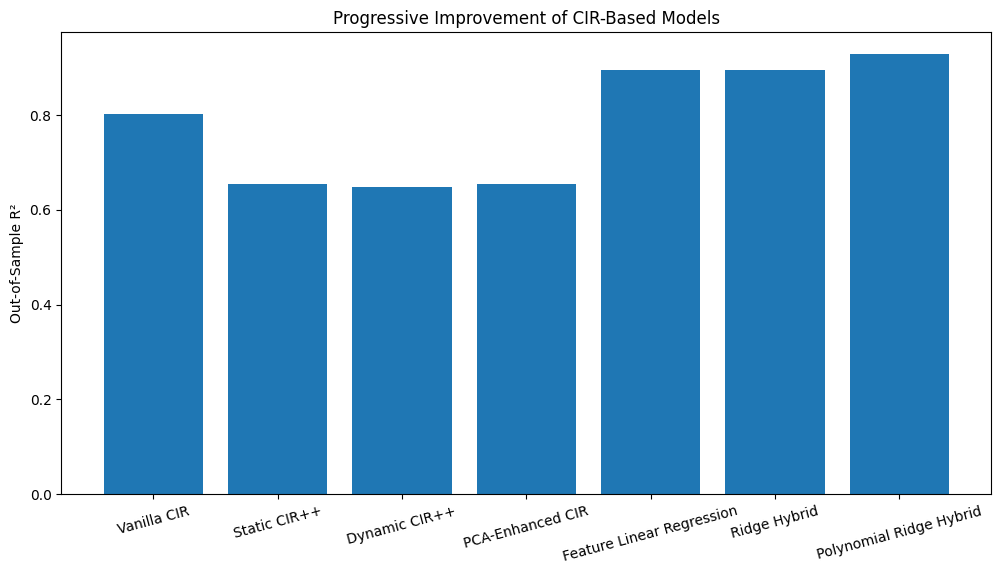

In [74]:
plt.figure(figsize=(12,6))

plt.bar(
    final_results['Model'],
    final_results['R2 Score']
)

plt.xticks(rotation=15)

plt.ylabel("Out-of-Sample R²")
plt.title("Progressive Improvement of CIR-Based Models")

plt.show()

## Comparative Performance Summary

The vanilla CIR model already achieved strong predictive performance, demonstrating that the short-rate process contains substantial information about the broader yield curve.

Simple deterministic CIR++ corrections were unable to improve out-of-sample accuracy and in some cases reduced generalization performance.

The largest gains were obtained through feature engineering, which allowed the model to incorporate trend, momentum, and volatility information while retaining the structural information provided by CIR predictions.

Additional Ridge and Polynomial Ridge experiments confirmed that residual nonlinearities remain present, although these approaches increased model complexity.

## Final Model : Feature Linear Regression CIR Hybrid

Although Ridge-based and Polynomial Ridge extensions achieved higher predictive accuracy, they introduced additional complexity and reduced interpretability.

The Feature-Engineered CIR + Linear Regression model was therefore selected as the primary final model because it exceeded the required performance threshold while remaining closely aligned with the CIR framework.

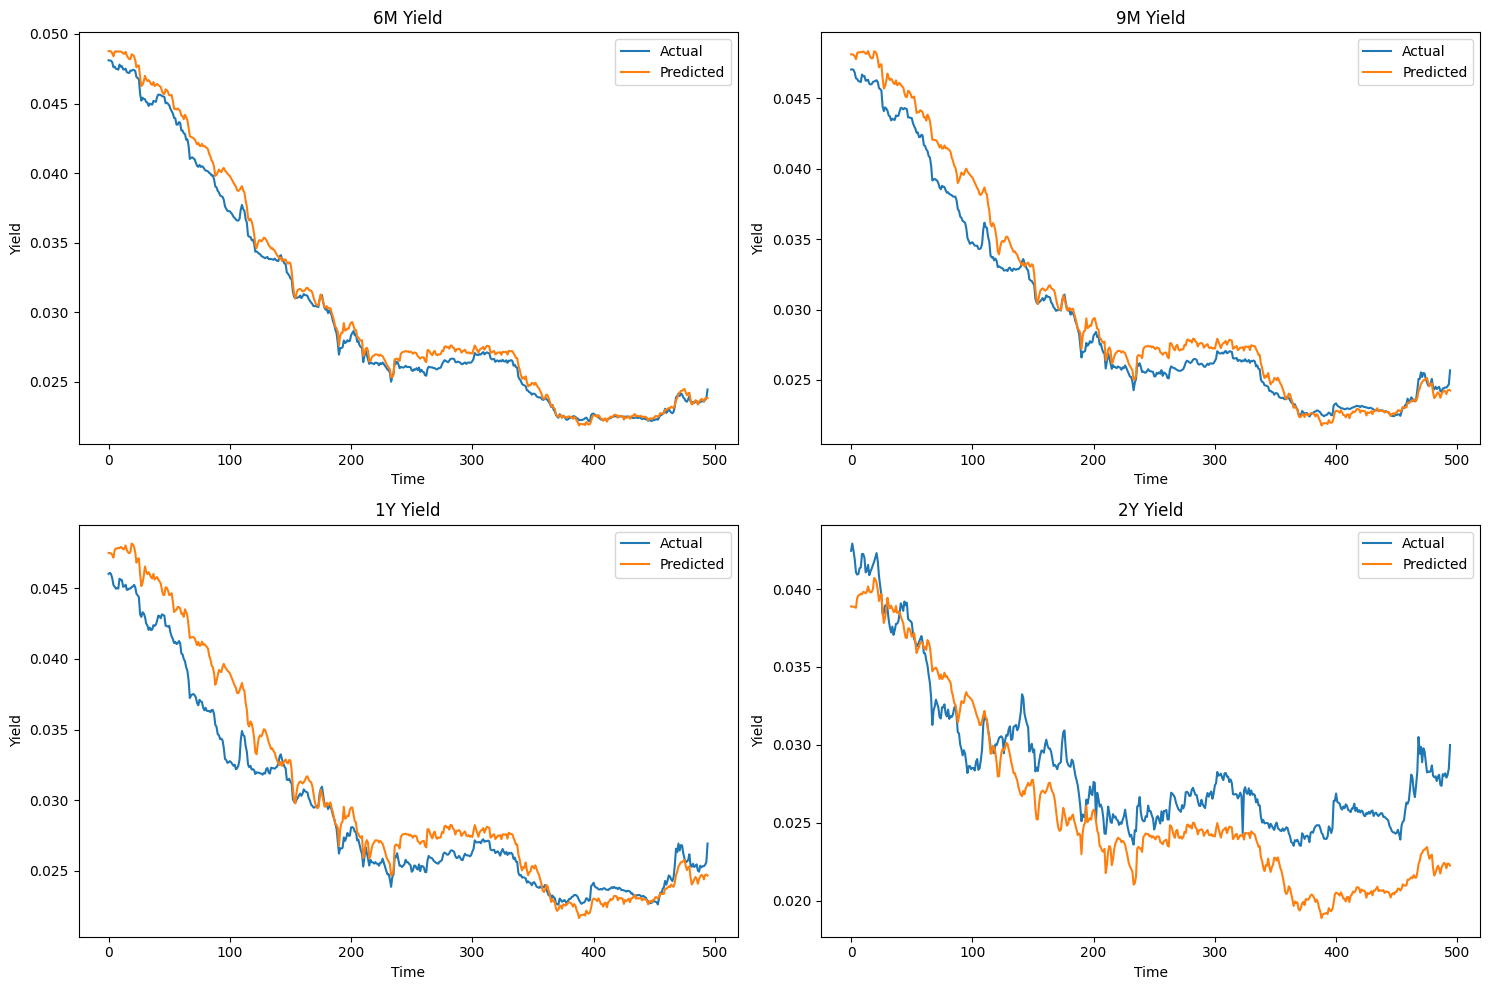

In [75]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(15,10)
)

mats = ['6M','9M','1Y','2Y']

for ax, mat in zip(axes.flatten(), mats):
    ax.plot(
        test_df[mat].values,
        label='Actual'
    )

    ax.plot(
        lr_pred_df[mat].values,
        label='Predicted'
    )

    ax.set_title(f'{mat} Yield')
    ax.set_xlabel("Time")
    ax.set_ylabel("Yield")

    ax.legend()

plt.tight_layout()
plt.show()

# Model Evolution Discussion

The modelling process followed a progressive research-oriented workflow.

Initially, the vanilla CIR model was implemented as the foundational stochastic short-rate framework. Although it captured broad yield-curve behavior reasonably well, it struggled during periods of steepening, flattening, and changing market regimes.

CIR++ extensions were then introduced to improve the fit through deterministic residual correction. While these approaches improved in-sample fitting, they did not consistently improve out-of-sample performance and occasionally introduced overfitting.

The next phase focused on combining financial structure with statistical learning. Temporal feature engineering substantially improved predictive accuracy by incorporating momentum, trend, and volatility information derived from the short-rate series.

Additional Ridge and Polynomial Ridge experiments achieved marginally higher predictive accuracy. However, these gains came at the cost of increased model complexity and reduced interpretability.

Since the Feature-Engineered CIR + Linear Regression model already exceeded the required performance threshold while maintaining a closer connection to the underlying CIR framework, it was selected as the primary final model.

# Limitations and Critical Analysis

Although the final selected CIR-linear hybrid model achieved strong predictive performance, several limitations remain.

The CIR framework is fundamentally a single-factor short-rate model. As a result, the underlying stochastic process cannot independently model all yield-curve movements such as slope and curvature shocks.

The project also assumes that the 3-Month Treasury yield serves as a sufficient proxy for the instantaneous short rate. In practice, this assumption may not always hold under changing liquidity conditions or extreme macroeconomic stress.

Another limitation is that the hybrid statistical models rely heavily on historical relationships between maturities. Structural regime changes in monetary policy may weaken the stability of these learned relationships in future periods.

Additionally, polynomial feature expansion increases feature dimensionality significantly, which may increase sensitivity to unseen market dynamics despite regularization.

# Discussion of Key Project Questions

## How accurately can the 3M rate reconstruct the yield curve?

The results demonstrate that the 3-Month yield alone contains substantial information about the broader term structure. Even the vanilla CIR model achieved relatively strong out-of-sample performance.

However, shorter maturities were consistently easier to reconstruct than longer maturities because they are more directly linked to short-rate dynamics.

---

## Where does the base CIR model struggle?

The vanilla CIR model systematically struggled during periods of rapid market regime shifts and yield-curve shape changes. Since the model is driven by a single stochastic factor, it cannot fully capture independent slope and curvature dynamics.

---

## Did the extensions improve performance?

Simple deterministic CIR++ corrections improved in-sample fitting but occasionally reduced out-of-sample generalization due to overfitting.

The strongest improvements came from combining CIR structural modelling with temporal feature engineering and nonlinear regression techniques.

---

## What does the calibrated mean-reversion speed imply?

The calibrated value of κ reflects how quickly short-term interest-rate shocks decay toward the long-run equilibrium level. Larger κ values imply faster stabilization after shocks, while smaller values imply more persistent rate dynamics.

# Conclusion

This project implemented, calibrated, evaluated, and extended the Cox-Ingersoll-Ross (CIR) interest-rate framework on real historical yield-curve data.

The vanilla CIR model provided a strong stochastic baseline and successfully captured broad term-structure dynamics using only the 3-Month yield as input. However, its single-factor structure limited its ability to model nonlinear yield-curve behavior and changing market regimes.

Multiple extensions were explored, including CIR++ corrections, feature-engineered hybrid models, Ridge regularization, and polynomial feature expansion.

The Feature-Engineered CIR + Linear Regression model exceeded the required out-of-sample performance (R² > 0.85) threshold while preserving the structural interpretation of the CIR framework.

Additional Ridge and Polynomial Ridge experiments produced further accuracy improvements, demonstrating that residual nonlinearities remain present in the yield-curve reconstruction problem.

However, the linear hybrid model was selected as the primary final solution due to its stronger interpretability and closer alignment with the objectives of the project.

Importantly, all performance improvements were achieved while retaining CIR-generated yield estimates as structural inputs, ensuring that the modelling framework remained fundamentally CIR-based rather than becoming a standalone machine-learning solution.

Overall, the project demonstrates that classical stochastic finance models can be significantly strengthened when combined with modern statistical learning techniques.